In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [3]:
import os
libpath="/content/drive/MyDrive/Data-Science/M5-deepLearning/Sheryians/project-1/movie-rec-main"
os.listdir(libpath)
df = pd.read_csv(libpath + "/movies_metadata.csv")
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [4]:
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [5]:
df.columns
#we dont no what should do with these no of columns so use chat gpt and gemini
# sentence = what should i use out of all of these columns to movie recomendation

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [7]:
df.shape

(45466, 24)

In [8]:
df.isnull().sum()
# belongs_to_collection	40972 ,homepage	37684  ,these data have large no of null values so we are not use this columns

,0
adult,0
belongs_to_collection,40972
budget,0
genres,0
homepage,37684
id,0
imdb_id,17
original_language,11
original_title,0
overview,954


In [9]:
df.duplicated().sum()
#no duplicate values 13

np.int64(13)

In [10]:
df = df.drop_duplicates().reset_index(drop = True)

In [11]:
df.duplicated().sum()
#no duplicate values 0

np.int64(0)

In [12]:
df = df[['title', 'overview', 'genres','tagline','vote_average','popularity']]

In [13]:
df

,title,overview,genres,tagline,vote_average,popularity
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",NaN,7.7,21.946943
1,Jumanji,When siblings Judy and Peter discover an encha...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",Roll the dice and unleash the excitement!,6.9,17.015539
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",Still Yelling. Still Fighting. Still Ready for...,6.5,11.7129
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",Friends are the people who let you be yourself...,6.1,3.859495
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,"[{'id': 35, 'name': 'Comedy'}]",Just When His World Is Back To Normal... He's ...,5.7,8.387519
...,...,...,...,...,...,...
45448,Subdue,Rising and falling between a man and woman.,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",Rising and falling between a man and woman,4.0,0.072051
45449,Century of Birthing,An artist struggles to finish his work while a...,"[{'id': 18, 'name': 'Drama'}]",NaN,9.0,0.178241
45450,Betrayal,"When one of her hits goes wrong, a professiona...","[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",A deadly game of wits.,3.8,0.903007
45451,Satan Triumphant,"In a small town live two brothers, one a minis...",[],NaN,0.0,0.003503


In [14]:
df.isnull().sum()

,0
title,6
overview,954
genres,0
tagline,25045
vote_average,6
popularity,5


In [15]:
df = df.dropna(subset=['title'])  #remove missing null values title row

In [16]:
df['overview'] = df['overview'].fillna('')   #in null space add an empty stace of overview column

In [17]:
df.iloc[0]['genres']

"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"

In [18]:
import ast
df['genres'] = df['genres'].apply(lambda x :" ".join([i['name'] for i in ast.literal_eval(x)]))

In [19]:
df['genres']

,genres
0,Animation Comedy Family
1,Adventure Fantasy Family
2,Romance Comedy
3,Comedy Drama Romance
4,Comedy
...,...
45448,Drama Family
45449,Drama
45450,Action Drama Thriller
45451,


In [20]:
df.head()

,title,overview,genres,tagline,vote_average,popularity
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",Animation Comedy Family,NaN,7.7,21.946943
1,Jumanji,When siblings Judy and Peter discover an encha...,Adventure Fantasy Family,Roll the dice and unleash the excitement!,6.9,17.015539
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,Romance Comedy,Still Yelling. Still Fighting. Still Ready for...,6.5,11.7129
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",Comedy Drama Romance,Friends are the people who let you be yourself...,6.1,3.859495
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,Comedy,Just When His World Is Back To Normal... He's ...,5.7,8.387519


In [21]:
df['tagline'] = df['tagline'].fillna('')

In [22]:
df.isnull().sum()

,0
title,0
overview,0
genres,0
tagline,0
vote_average,0
popularity,0


In [23]:
df['tags'] = df['overview']+ " " + df['genres'] +" "+ df['tagline']

In [24]:
df.head()

,title,overview,genres,tagline,vote_average,popularity,tags
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",Animation Comedy Family,,7.7,21.946943,"Led by Woody, Andy's toys live happily in his ..."
1,Jumanji,When siblings Judy and Peter discover an encha...,Adventure Fantasy Family,Roll the dice and unleash the excitement!,6.9,17.015539,When siblings Judy and Peter discover an encha...
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,Romance Comedy,Still Yelling. Still Fighting. Still Ready for...,6.5,11.7129,A family wedding reignites the ancient feud be...
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",Comedy Drama Romance,Friends are the people who let you be yourself...,6.1,3.859495,"Cheated on, mistreated and stepped on, the wom..."
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,Comedy,Just When His World Is Back To Normal... He's ...,5.7,8.387519,Just when George Banks has recovered from his ...


In [25]:
df['tags'][1]

"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures. Adventure Fantasy Family Roll the dice and unleash the excitement!"

In [26]:
# remove punctuation,stopwords,lemmatization, split word
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re  # regularization expression


In [27]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [28]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [29]:
def preprocess_text(text):
  #lowercase
  text = str(text).lower()

  #removed the punctuations
  text = re.sub(r'[^a-zA-Z\s]', '', text)

  words = text.split()  # tokenise word EX. how are you === ['how','are','you']

  #remove stopwords
  words = [word for word in words if word not in stop_words]

  #lemmatize
  words = [lemmatizer.lemmatize(word) for word in words]

  return " ".join(words) # join list to string



In [30]:
df['tags'] = df['tags'].apply(preprocess_text)

In [31]:
df['tags'][1] # remove everything after using preprocess function

'sibling judy peter discover enchanted board game open door magical world unwittingly invite alan adult who trapped inside game year living room alans hope freedom finish game prof risky three find running giant rhinoceros evil monkey terrifying creature adventure fantasy family roll dice unleash excitement'

**After that now convert each sentence in vectors form**

convert word to number

In [32]:
df = df.reset_index(drop = True)

In [33]:
indices = pd.Series(df.index,index = df['title']).drop_duplicates()
indices

,0
title,
Toy Story,0
Jumanji,1
Grumpier Old Men,2
Waiting to Exhale,3
Father of the Bride Part II,4
...,...
Subdue,45442
Century of Birthing,45443
Betrayal,45444


In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [35]:
tfidf = TfidfVectorizer(max_features=50000,ngram_range=(1,2),stop_words='english')

In [36]:
tfidf_matrix = tfidf.fit_transform(df['tags'])

In [37]:
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1548114 stored elements and shape (45447, 50000)>

**Find similarity using cosine similarity liabrary**

In [38]:
from sklearn.metrics.pairwise import cosine_similarity


In [42]:
def recommend(title, n = 10):
  if title not in indices:
    return ['Movie not found']

  idx = indices[title]
  sim_score = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
  # tfidf geting one sinle movie matrix of index and this matrix compare withall matrix
  #flatten getting the multidimentional array to single dimentional array
  similar_idx = sim_score.argsort()[::-1][1:n+1]  # sort karte hai to on the basis of value but we want index so use argsort so i am
  #  getting values from -vet index to last 10 movies getting top 10 movies
  return df['title'].iloc[similar_idx]


In [45]:
recommend('Toy Story')

,title
2996,Toy Story 2
15344,Toy Story 3
24512,Small Fry
28972,Superstar Goofy
17184,Group Sex
6434,"What's Up, Tiger Lily?"
11396,For Your Consideration
1071,Rebel Without a Cause
1931,Condorman
485,Malice


In [44]:
recommend('Avatar',5)

,title
26547,Avatar 2
13883,The Inhabited Island
26553,Thor: Ragnarok
43431,Moontrap: Target Earth
14119,The Three Musketeers


In [47]:
import pickle

pickle.dump(tfidf_matrix,open(libpath + '/tfidf_matrix.pkl','wb'))

pickle.dump(indices,open(libpath + '/indices.pkl','wb'))

df.to_pickle(libpath +'/df.pkl') #dataframe i.e dataset

pickle.dump(tfidf,open(libpath + '/tfidf.pkl','wb'))

# Cosine similarity

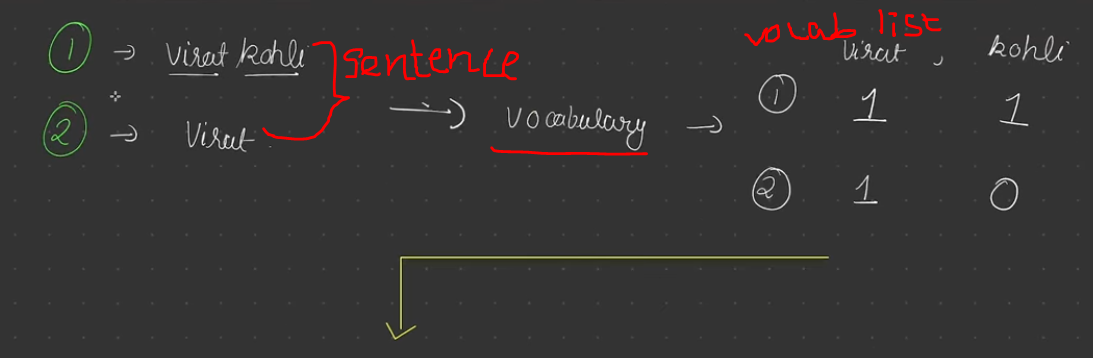

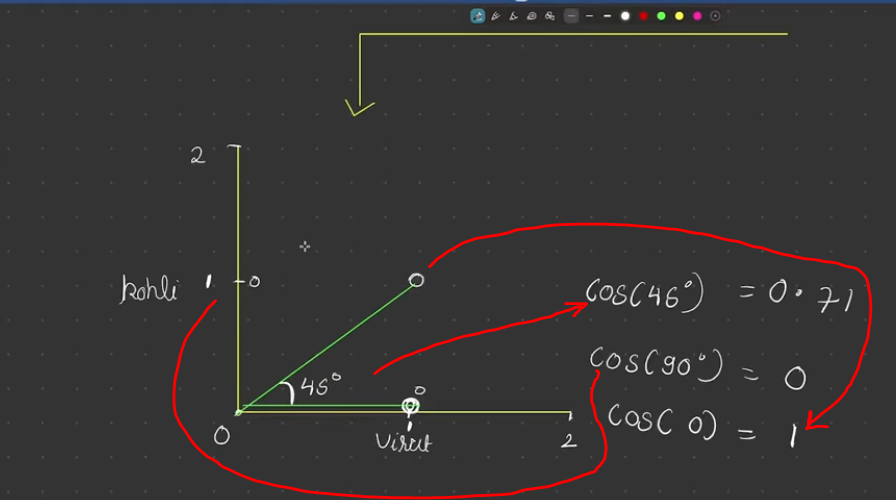

I above picture we see 3 scenario :-

a) first scenario
  1) virat kohli  
  2)virat
in first sentence point is center of the axis and second point is x-axis so in between create a angle 45 degree now calculate the

**cos(45 degree) = 0.71**

b) second scenario
  1) virat   
  2) kohli
in first sentence point is x-axis and second point is y-axis so in between create a angle 90 degree now calculate the

  **cos(90 degree) = 0**

c) third scenario
  1) virat kohli  
  2)virat kohli
in both sentence point is same so in between create a angle 0 degree now calculate the

**cos(0 degree) = 1**

* we used the graph cause our statements were small but in real world our statements will be very big.

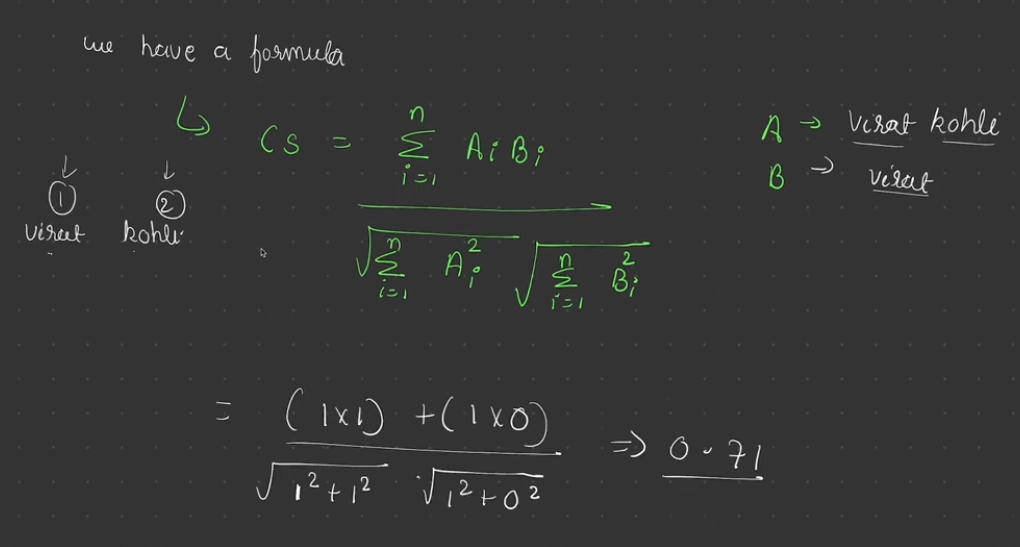